# S&P 500 — shared multi-ticker LSTM (multi-step + auxiliary mean)

One **shared** model over **aligned** trading days (inner join on `Date`), following the same Functional API pattern as [`keras/tutorials/keras-multi-output-2026-working.ipynb`](../tutorials/keras-multi-output-2026-working.ipynb):

- **Input**: `(lookback, K)` where **K** is the number of tickers — each channel is that ticker’s **Adj Close** (z-scored on the training segment, per ticker column).
- **Multi-step × multi-ticker** (`adj_close_path`): shape `(K, H)` — for each ticker, the next **H** **residuals** in normalized space vs the last bar of the window.
- **Auxiliary** (`horizon_mean_residual`): shape `(K,)`, mean of those H residuals per ticker (weighted with `loss_weights`).

**Dataset**: [camnugent/sandp500](https://www.kaggle.com/datasets/camnugent/sandp500); locally via `kagglehub` or `data/sandp500/`. Uses **Close** when **Adj Close** is missing.

Tune auxiliary weight with env `SNP_AUX_MEAN_WEIGHT` (default `0.35`). Optional: `SNP_TICKERS=AAPL,MSFT,...` (comma-separated) to shrink **K** for quick runs.

**CLI / smoke test**: from `keras/`, run `python standard-poors/snp_panel_lstm_multi_output.py --debug` (synthetic panel, no CSV; add `--no-plot` if needed). Full runs omit `--debug` and use the same env vars as this notebook (`SNP_LOOKBACK`, `SNP_HORIZON`, `SNP_EPOCHS`, `SNP_BATCH`, `SNP_LR`, …).


## Setup

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import keras

# --- snp_panel_lstm_multi_output.py (library section; CLI entrypoint is the .py file) ---

_CANONICAL_COL = {
    "date": "Date",
    "open": "Open",
    "high": "High",
    "low": "Low",
    "close": "Close",
    "adj close": "Adj Close",
    "adj_close": "Adj Close",
    "volume": "Volume",
    "name": "Name",
    "symbol": "Symbol",
    "ticker": "Symbol",
    "company_name": "Name",
    "company name": "Name",
}


def _canonicalize_ohlcv_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out.columns = [_CANONICAL_COL.get(c.strip().lower(), c.strip()) for c in out.columns]
    return out


def _ticker_column(df: pd.DataFrame) -> str:
    for c in ("Name", "Symbol"):
        if c in df.columns:
            return c
    raise ValueError(
        "Need a ticker/name column (Name, Symbol, …). " f"Columns: {list(df.columns)}"
    )


def _is_kaggle() -> bool:
    return bool(os.environ.get("KAGGLE_KERNEL_RUN_TYPE")) or Path("/kaggle").exists()


def _local_data_roots():
    cwd = Path.cwd()
    return [cwd, cwd / "standard-poors", cwd.parent / "standard-poors"]


def resolve_sandp500_csv() -> Path:
    kaggle_roots = [
        Path("/kaggle/input/sandp500"),
        Path("/kaggle/input/camnugent-sandp500"),
        Path("/kaggle/input/sp500"),
    ]
    for root in kaggle_roots:
        if not root.is_dir():
            continue
        for name in ("all_stocks_5yr.csv", "all_stocks.csv"):
            p = root / name
            if p.is_file():
                return p
        found = list(root.rglob("all_stocks*.csv"))
        if found:
            return found[0]

    try:
        import kagglehub

        root = Path(kagglehub.dataset_download("camnugent/sandp500"))
        for name in ("all_stocks_5yr.csv", "all_stocks.csv"):
            p = root / name
            if p.is_file():
                return p
        found = list(root.rglob("all_stocks*.csv"))
        if found:
            return found[0]
    except Exception:
        pass

    for base in _local_data_roots():
        local = base / "data" / "sandp500"
        if local.is_dir():
            found = list(local.rglob("all_stocks*.csv")) + list(local.rglob("*.csv"))
            if found:
                return found[0]

    raise FileNotFoundError(
        "Could not find S&P 500 CSV. On Kaggle, add dataset camnugent/sandp500. "
        "Locally: pip install kagglehub and authenticate, or copy CSV under standard-poors/data/sandp500/. "
        "Or set DEBUG_MODE = True in the next cell (synthetic panel)."
    )


def load_ticker_ohlcv(csv_path: Path, ticker: str) -> pd.DataFrame:
    df = _canonicalize_ohlcv_columns(pd.read_csv(csv_path))
    name_col = _ticker_column(df)
    if "Date" not in df.columns:
        raise ValueError(f"Expected a date column; got {list(df.columns)}")

    needle = ticker.strip().upper()
    sub = df[df[name_col].astype(str).str.strip().str.upper() == needle].copy()
    if sub.empty:
        raise ValueError(
            f"No rows for ticker {ticker!r} in column {name_col!r}. "
            f"Sample values: {df[name_col].dropna().astype(str).unique()[:8].tolist()}"
        )

    sub["Date"] = pd.to_datetime(sub["Date"], utc=True, errors="coerce")
    sub = sub.sort_values("Date").reset_index(drop=True)

    if "Adj Close" not in sub.columns:
        if "Close" not in sub.columns:
            raise ValueError(f"Need Adj Close or Close; columns are {list(sub.columns)}")
        sub["Adj Close"] = sub["Close"]
        if not getattr(load_ticker_ohlcv, "_warned_no_adj", False):
            print(
                "Note: CSV has no 'Adj Close' column; using 'Close' as the price series "
                "(camnugent/sandp500 is unadjusted)."
            )
            load_ticker_ohlcv._warned_no_adj = True

    return sub[["Adj Close", "Date"]]


def normalize(data: np.ndarray, train_split: int) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    data_mean = data[:train_split].mean(axis=0)
    data_std = data[:train_split].std(axis=0)
    data_std = np.where(data_std == 0, 1.0, data_std)
    return (data - data_mean) / data_std, data_mean, data_std


def align_panel_prices(ohlcv_by_ticker: dict[str, pd.DataFrame]) -> tuple[pd.DataFrame, pd.Series]:
    tickers = list(ohlcv_by_ticker.keys())
    merged = None
    for t in tickers:
        df = ohlcv_by_ticker[t][["Date", "Adj Close"]].copy()
        df["Date"] = pd.to_datetime(df["Date"], utc=True, errors="coerce")
        df = df.rename(columns={"Adj Close": t}).dropna(subset=["Date"])
        part = df.set_index("Date")[[t]]
        merged = part if merged is None else merged.join(part, how="inner")
    merged = merged.sort_index().reset_index()
    dates = merged["Date"]
    panel = merged[tickers]
    return panel, dates


def synthetic_aligned_panel(
    n_rows: int, tickers: list[str], seed: int = 0
) -> tuple[pd.DataFrame, pd.Series]:
    """Random-walk prices on a business-day calendar (no CSV)."""
    rng = np.random.default_rng(seed)
    dates = pd.date_range("2020-01-01", periods=n_rows, freq="B", tz="UTC")
    inc = rng.standard_normal((n_rows, len(tickers))).astype(np.float64) * 0.4
    levels = 100.0 + np.cumsum(inc, axis=0)
    panel = pd.DataFrame(levels, columns=tickers)
    return panel, pd.Series(dates)


def build_arrays_panel_multi_output(
    panel: pd.DataFrame, lookback: int, horizon: int, train_frac: float
):
    values = panel.values.astype(np.float64)
    n, n_tickers = values.shape
    split = int(n * train_frac)
    if split <= lookback + horizon + 10:
        raise ValueError("Not enough rows for lookback, horizon, and split.")

    norm, mean, std = normalize(values, split)

    def windows(start: int, end: int):
        xs, path, mean_res = [], [], []
        last = end - lookback - horizon
        for i in range(start, last + 1):
            win = norm[i : i + lookback]
            anchor = win[-1, :]
            fut = norm[i + lookback : i + lookback + horizon, :]
            resid = fut - anchor
            xs.append(win)
            path.append(resid.T)
            mean_res.append(np.mean(resid, axis=0))
        return (
            np.asarray(xs, dtype=np.float32),
            np.asarray(path, dtype=np.float32),
            np.asarray(mean_res, dtype=np.float32),
        )

    train_end = split
    x_tr, p_tr, m_tr = windows(0, train_end)
    x_va, p_va, m_va = windows(split, n)
    y_tr = {"adj_close_path": p_tr, "horizon_mean_residual": m_tr}
    y_va = {"adj_close_path": p_va, "horizon_mean_residual": m_va}
    return (x_tr, y_tr, x_va, y_va), {"mean": mean, "std": std}


def make_panel_model(
    lookback: int,
    n_tickers: int,
    horizon: int,
    lstm_units: int,
    lr: float,
    aux_mean_weight: float,
):
    inputs = keras.layers.Input(shape=(lookback, n_tickers), name="window")
    last = inputs[:, -1, :]
    u2 = max(lstm_units // 2, 8)
    dense_hidden = max(lstm_units // 2, 32)
    x = keras.layers.LSTM(lstm_units, return_sequences=True)(inputs)
    x = keras.layers.Dropout(0.6)(x)
    x = keras.layers.LSTM(u2)(x)
    x = keras.layers.Dropout(0.6)(x)
    x = keras.layers.Concatenate()([x, last])
    x = keras.layers.Dense(dense_hidden, activation="relu")(x)
    x = keras.layers.Dropout(0.5)(x)
    flat_h = n_tickers * horizon
    path_flat = keras.layers.Dense(flat_h)(x)
    out_path = keras.layers.Reshape((n_tickers, horizon), name="adj_close_path")(path_flat)
    out_mean = keras.layers.Dense(n_tickers, name="horizon_mean_residual")(x)
    model = keras.Model(
        inputs=inputs,
        outputs={"adj_close_path": out_path, "horizon_mean_residual": out_mean},
    )
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss={
            "adj_close_path": "mse",
            "horizon_mean_residual": "mse",
        },
        loss_weights={
            "adj_close_path": 1.0,
            "horizon_mean_residual": aux_mean_weight,
        },
        metrics={
            "adj_close_path": ["mae"],
            "horizon_mean_residual": ["mae"],
        },
    )
    return model


def parse_tickers(raw: str) -> list[str]:
    return [t.strip().upper() for t in raw.split(",") if t.strip()]


print("Kaggle kernel:", _is_kaggle())


Kaggle kernel: False


## Load data

With **`DEBUG_MODE = True`** in the next cell, uses `synthetic_aligned_panel` (same as `python snp_panel_lstm_multi_output.py --debug`). With **`False`**, resolves the S&P CSV (Kaggle input → `kagglehub` → local `data/sandp500/`).


In [2]:
# Same as: python snp_panel_lstm_multi_output.py [--debug]
# DEBUG_MODE True → synthetic panel (fast smoke test); False → S&P CSV via resolve_sandp500_csv()
DEBUG_MODE = False

N_PLOT_SLICES = 5
BASELINE_WINDOW = int(os.environ.get("SNP_BASELINE_WINDOW", "7"))

if DEBUG_MODE:
    TICKERS = ["AAA", "BBB", "CCC"]
    LOOKBACK = 16
    HORIZON = 5
    TRAIN_FRAC = 0.75
    LSTM_UNITS = 32
    panel_prices, panel_dates = synthetic_aligned_panel(220, TICKERS, seed=42)
    print(f"[debug] Synthetic panel: {len(panel_prices)} rows × {len(TICKERS)} tickers")
else:
    _raw = os.environ.get("SNP_TICKERS", "AAPL,MSFT,GOOG,AMZN,JPM")
    TICKERS = parse_tickers(_raw)
    LOOKBACK = int(os.environ.get("SNP_LOOKBACK", "60"))
    HORIZON = int(os.environ.get("SNP_HORIZON", "20"))
    TRAIN_FRAC = float(os.environ.get("SNP_TRAIN_FRAC", "0.8"))
    LSTM_UNITS = int(os.environ.get("SNP_LSTM_UNITS", "128"))

    csv_path = resolve_sandp500_csv()
    print("Using CSV:", csv_path)
    ohlcv_by_ticker = {t: load_ticker_ohlcv(csv_path, t) for t in TICKERS}
    panel_prices, panel_dates = align_panel_prices(ohlcv_by_ticker)
    print(
        f"Aligned panel: {len(panel_prices)} rows × {len(TICKERS)} tickers (inner join on Date)"
    )

panel_prices.tail()


/Users/nicapotato/Documents/repo/project/KaggleNotebooks/keras/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using CSV: /Users/nicapotato/.cache/kagglehub/datasets/camnugent/sandp500/versions/4/all_stocks_5yr.csv
Note: CSV has no 'Adj Close' column; using 'Close' as the price series (camnugent/sandp500 is unadjusted).
Aligned panel: 975 rows × 5 tickers (inner join on Date)


,AAPL,MSFT,GOOG,AMZN,JPM
970,167.78,94.26,1167.70,1390.00,116.87
971,160.50,91.78,1111.90,1429.95,114.28
972,156.49,88.00,1055.80,1390.00,108.80
973,163.03,91.33,1080.60,1442.84,112.11
974,159.54,89.61,1048.58,1416.78,112.87


## Windows + targets (shared calendar)

**Normalization**: on the stacked matrix `panel_prices.values`, each **ticker column** is z-scored using the **training rows only** (`train_split = int(n * TRAIN_FRAC)`), same spirit as the [Keras weather tutorial](https://keras.io/examples/timeseries/timeseries_weather_forecasting/).

Each sample:

- **Input** `x`: `(lookback, K)` — last `lookback` **shared** dates, `K` tickers.
- **`adj_close_path`**: `(K, H)` — multi-step residuals per ticker.
- **`horizon_mean_residual`**: `(K,)` — auxiliary mean per ticker.

Plots and USD MAE use **`adj_close_path`**; denormalize with per-ticker `mean[k], std[k]` and add the last-window anchor `x[:, -1, k]`.


In [3]:
(x_train, y_train, x_val, y_val), scaler = build_arrays_panel_multi_output(
    panel_prices, LOOKBACK, HORIZON, TRAIN_FRAC
)
print(
    f"x_train {x_train.shape}, adj_close_path {y_train['adj_close_path'].shape}, "
    f"horizon_mean_residual {y_train['horizon_mean_residual'].shape}"
)


x_train (701, 60, 5), adj_close_path (701, 5, 20), horizon_mean_residual (701, 5)


In [4]:
x_train[0].shape, y_train["adj_close_path"][0].shape, y_train["horizon_mean_residual"][0].shape


((60, 5), (5, 20), (5,))

## Model: one LSTM — `adj_close_path` `(K, H)` + `horizon_mean_residual` `(K)`

Weighted losses (`loss_weights`); early stopping on aggregate `val_loss`.


In [5]:
LR = float(os.environ.get("SNP_LR", "1e-3"))
AUX_MEAN_WEIGHT = float(os.environ.get("SNP_AUX_MEAN_WEIGHT", "0.35"))

model = make_panel_model(
    LOOKBACK,
    len(TICKERS),
    HORIZON,
    lstm_units=LSTM_UNITS,
    lr=LR,
    aux_mean_weight=AUX_MEAN_WEIGHT,
)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ window (InputLayer) │ (None, 60, 5)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 60, 128)   │     68,608 │ window[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 60, 128)   │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 64)        │     49,408 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 5)         │          0 │ window[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 69)        │          0 │ dropout_1[0][0],  │
│ (Concatenate)       │                   │            │ get_item[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      4,480 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 100)       │      6,500 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ adj_close_path      │ (None, 5, 20)     │          0 │ dense_1[0][0]     │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ horizon_mean_resid… │ (None, 5)         │        325 │ dropout_2[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 129,321 (505.16 KB)

 Trainable params: 129,321 (505.16 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
BATCH_SIZE = int(os.environ.get("SNP_BATCH", "64"))
EPOCHS = int(os.environ.get("SNP_EPOCHS", "1000"))
ES_PATIENCE = 5 if DEBUG_MODE else 40

es = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=ES_PATIENCE,
    restore_best_weights=True,
)
history = model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[es],
    verbose=1,
)
print(f"Finished after {len(history.history['loss'])} epochs (max {EPOCHS})")

_k = len(TICKERS)
_pred = model.predict(x_val[: min(8, len(x_val))], verbose=0)
assert _pred["adj_close_path"].shape[-2:] == (_k, HORIZON)
assert _pred["horizon_mean_residual"].shape[-1] == _k
print("Predict shapes OK:", _pred["adj_close_path"].shape, _pred["horizon_mean_residual"].shape)


Epoch 1/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - adj_close_path_loss: 0.1062 - adj_close_path_mae: 0.2467 - horizon_mean_residual_loss: 0.1364 - horizon_mean_residual_mae: 0.2875 - loss: 0.1539 - val_adj_close_path_loss: 0.1272 - val_adj_close_path_mae: 0.2652 - val_horizon_mean_residual_loss: 0.0964 - val_horizon_mean_residual_mae: 0.2433 - val_loss: 0.1590
Epoch 2/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - adj_close_path_loss: 0.1037 - adj_close_path_mae: 0.2430 - horizon_mean_residual_loss: 0.1236 - horizon_mean_residual_mae: 0.2725 - loss: 0.1469 - val_adj_close_path_loss: 0.1292 - val_adj_close_path_mae: 0.2677 - val_horizon_mean_residual_loss: 0.0961 - val_horizon_mean_residual_mae: 0.2391 - val_loss: 0.1606
Epoch 3/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - adj_close_path_loss: 0.1020 - adj_close_path_mae: 0.2413 - horizon_mean_residual_loss: 0.1234 - horizon_mean_residual_mae: 0.2767 - loss: 0.1452 - val_adj_close_path_loss: 0.1341 - val_adj_close_path_mae: 0.2710

## Loss curves

**Aggregate `val_loss`** is the weighted sum of the two MSE heads. Per-output keys may appear as `val_adj_close_path_loss`, etc., depending on Keras version.

**Chronological** split — no shuffle on this time series.


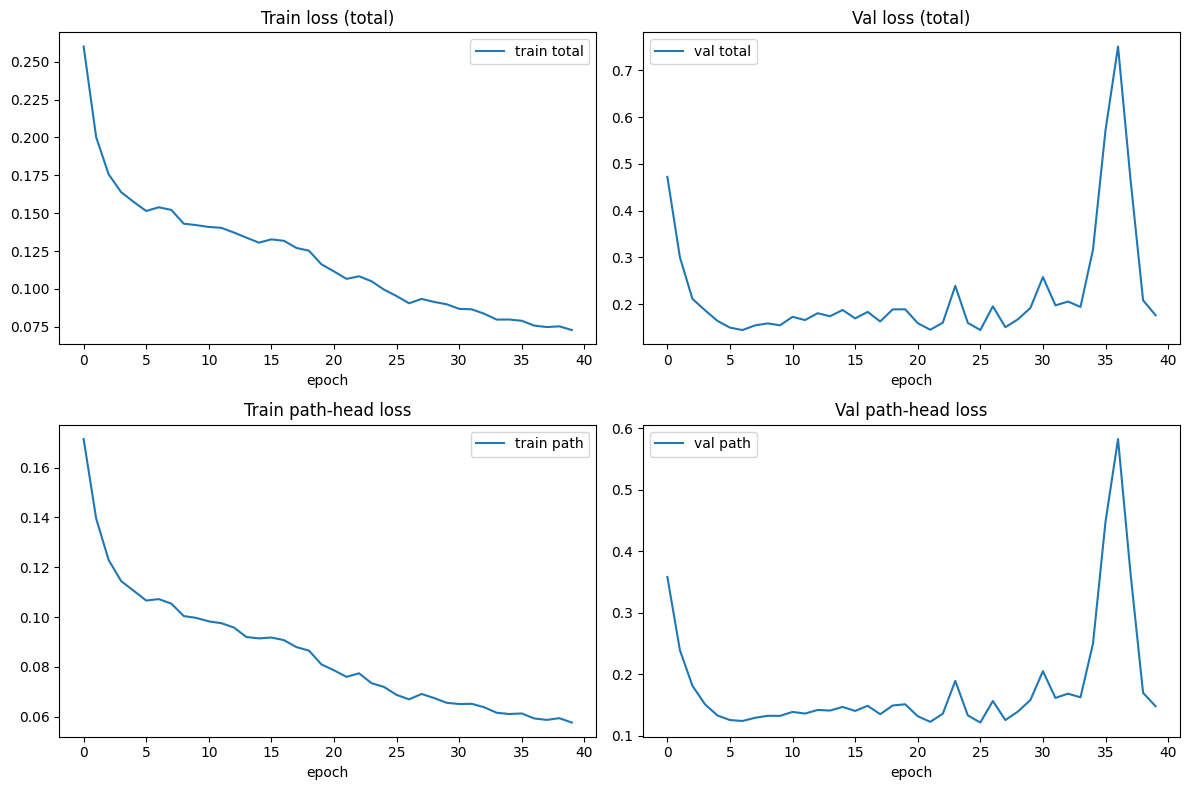

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
ax_tl, ax_tr, ax_bl, ax_br = axes[0, 0], axes[0, 1], axes[1, 0], axes[1, 1]
h = history.history
ax_tl.plot(h["loss"], label="train total")
ax_tr.plot(h["val_loss"], label="val total")
pk = next((k for k in h if k.endswith("adj_close_path_loss") and not k.startswith("val_")), None)
vk = next((k for k in h if k.endswith("adj_close_path_loss") and k.startswith("val_")), None)
if pk:
    ax_bl.plot(h[pk], label="train path")
if vk:
    ax_br.plot(h[vk], label="val path")
ax_tl.set_title("Train loss (total)")
ax_tr.set_title("Val loss (total)")
ax_bl.set_title("Train path-head loss")
ax_br.set_title("Val path-head loss")
for ax in axes.flat:
    ax.legend()
    ax.set_xlabel("epoch")
plt.tight_layout()
plt.show()


## Qualitative check: forecasts per ticker (shared model)

Forecasts use the **`adj_close_path`** head only for levels; **`horizon_mean_residual`** is auxiliary.

- **Top / bottom rows**: train + validation **Adj Close** from the **aligned panel**; dashed line at the chronological split.
- **Bottom subplot**: next `HORIZON` steps — actual, LSTM, and rolling-mean baseline (last `BASELINE_WINDOW` bars before the forecast origin).


AAPL Val MAE: model=4.0877 USD | rolling-7 baseline=4.7752 USD


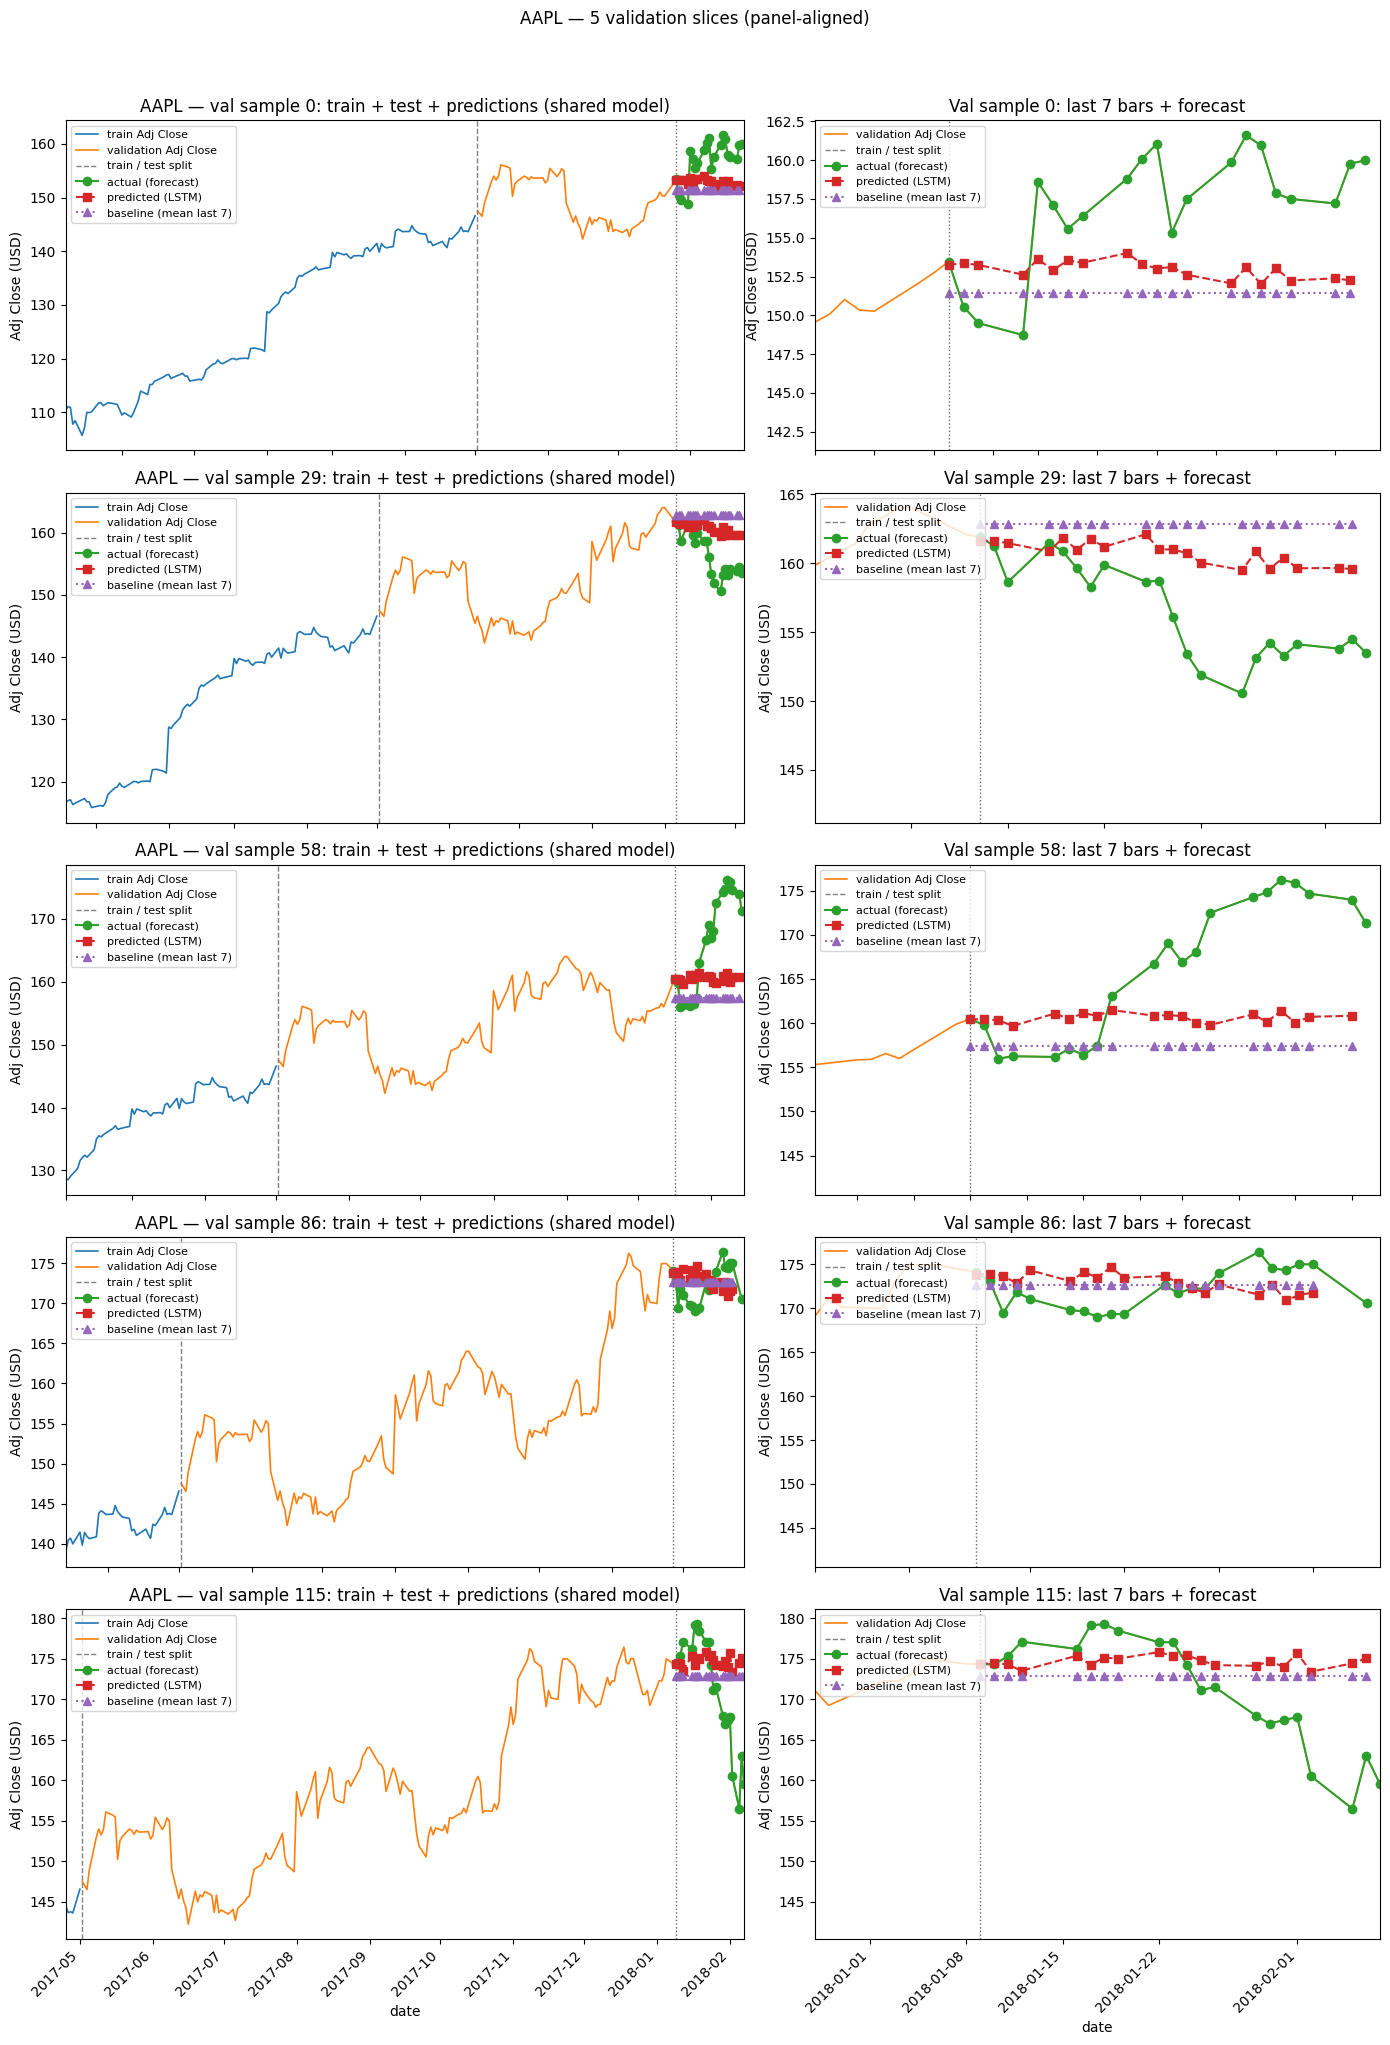

MSFT Val MAE: model=2.2351 USD | rolling-7 baseline=2.3190 USD


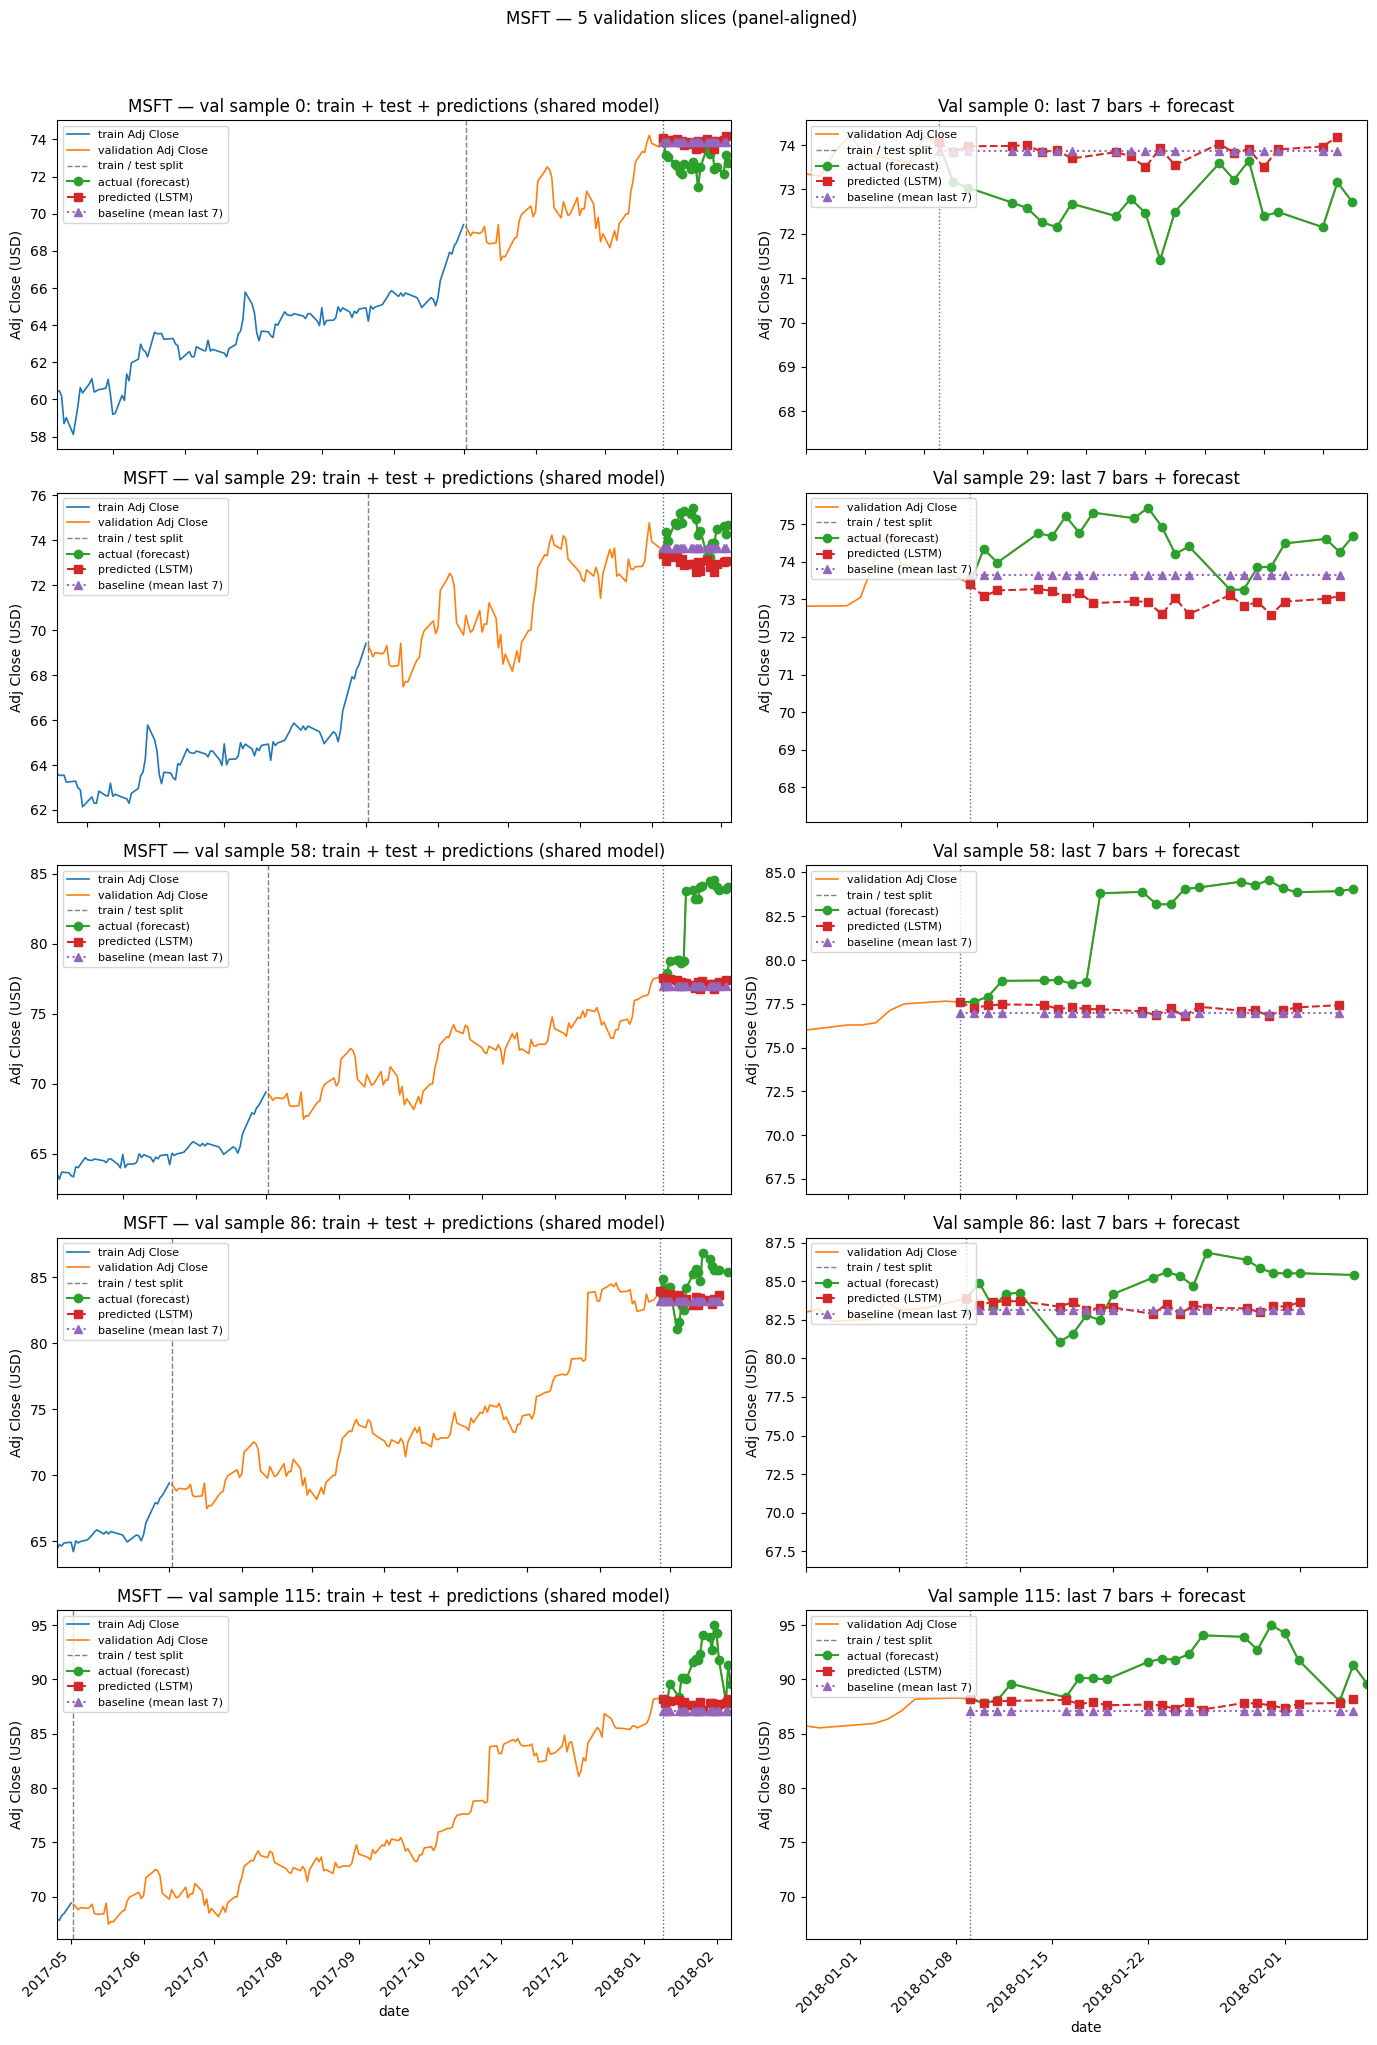

GOOG Val MAE: model=27.1004 USD | rolling-7 baseline=29.6680 USD


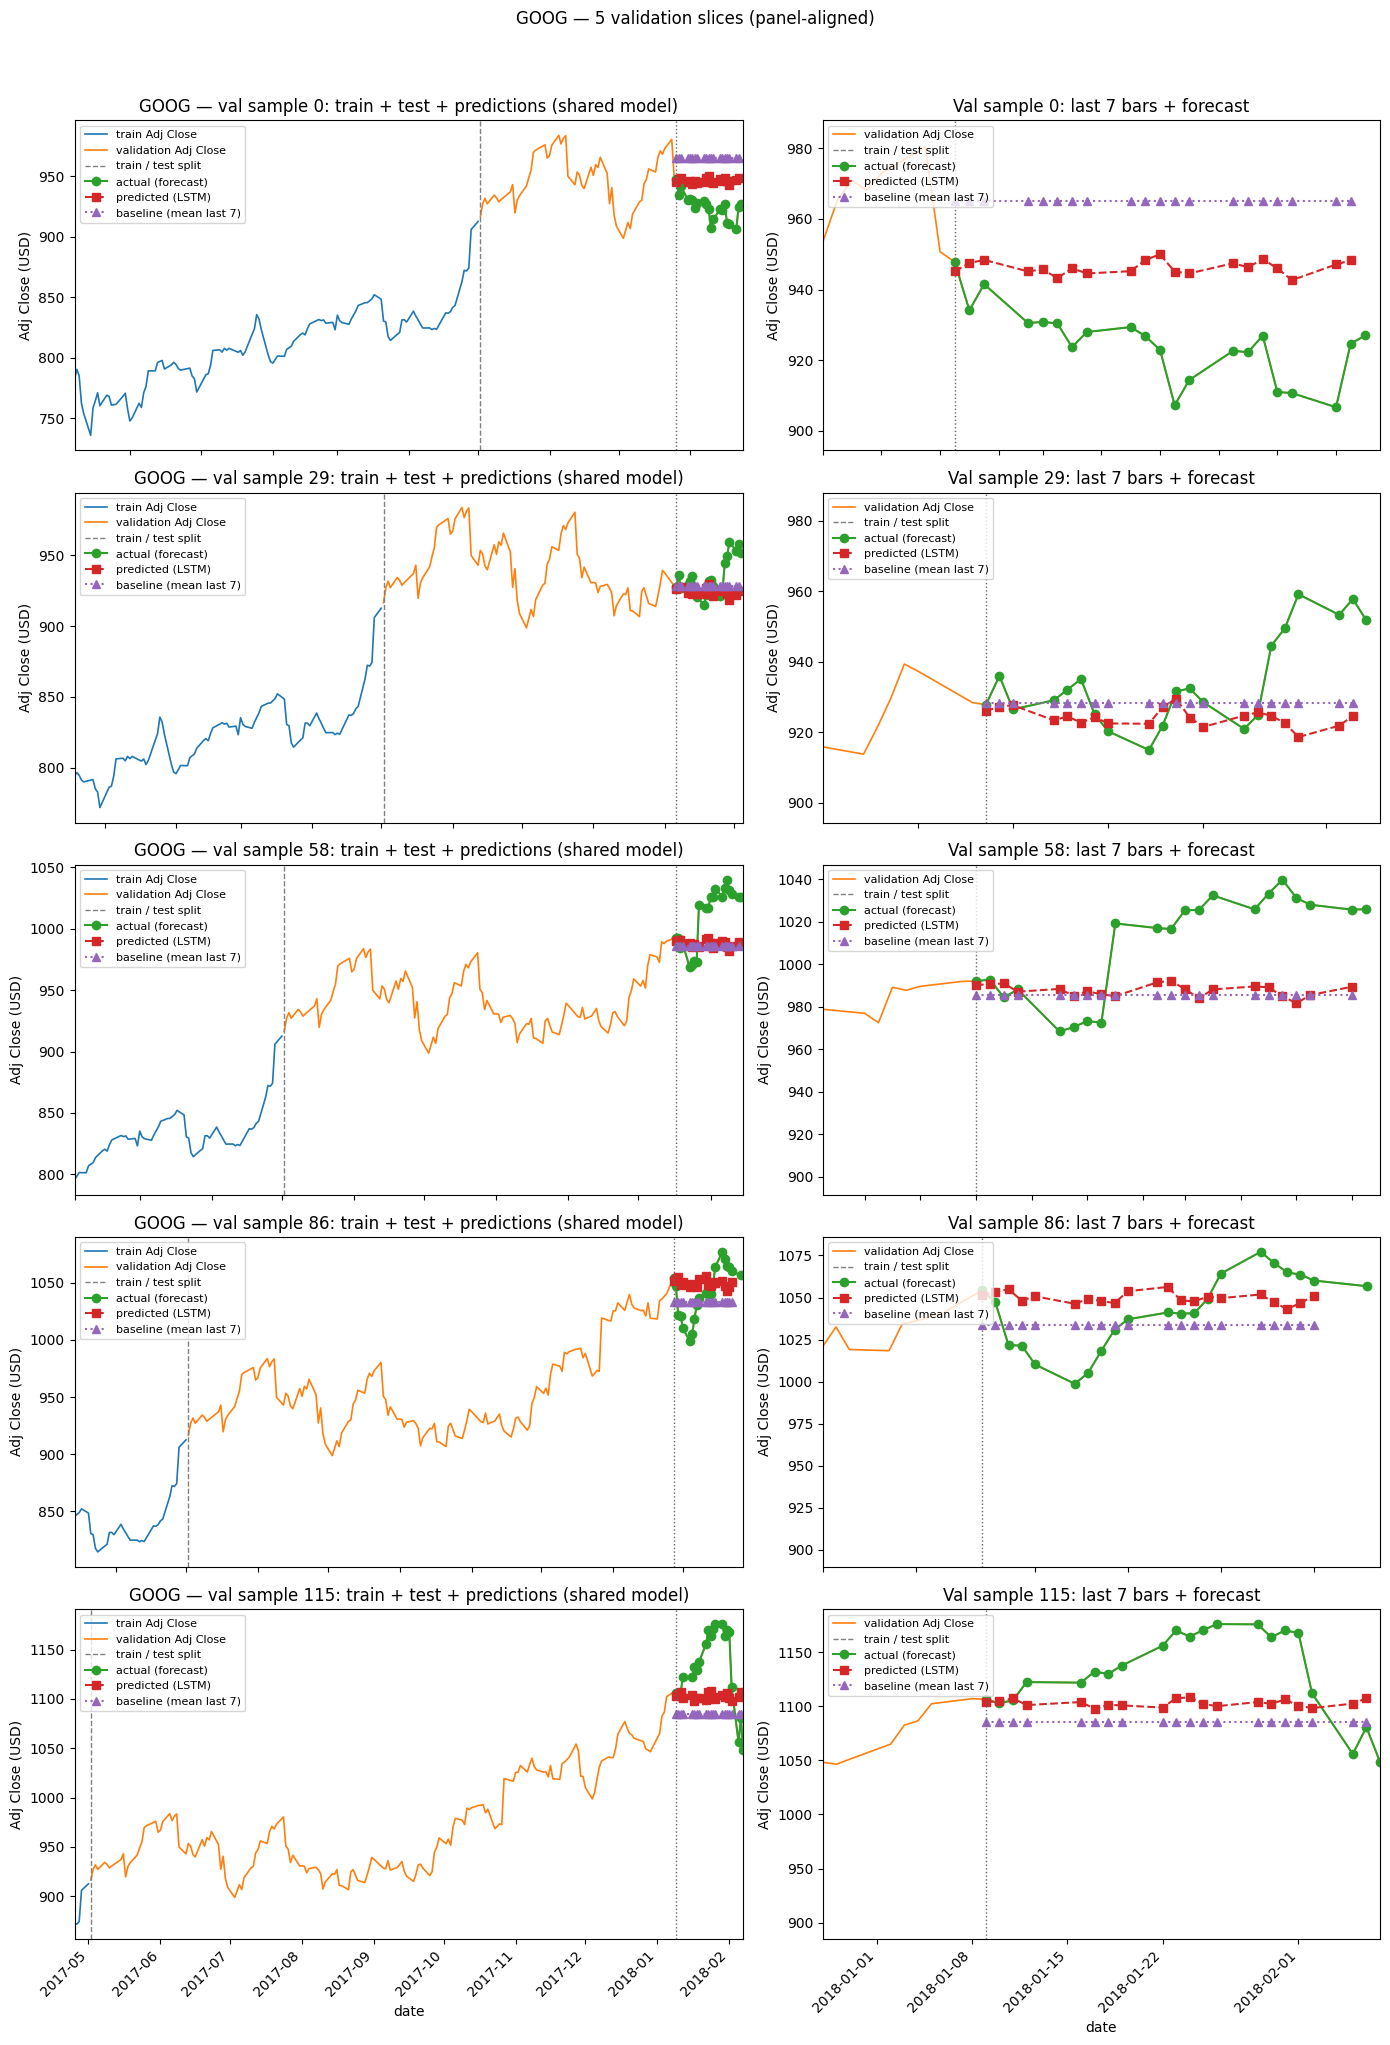

AMZN Val MAE: model=40.0503 USD | rolling-7 baseline=49.8840 USD


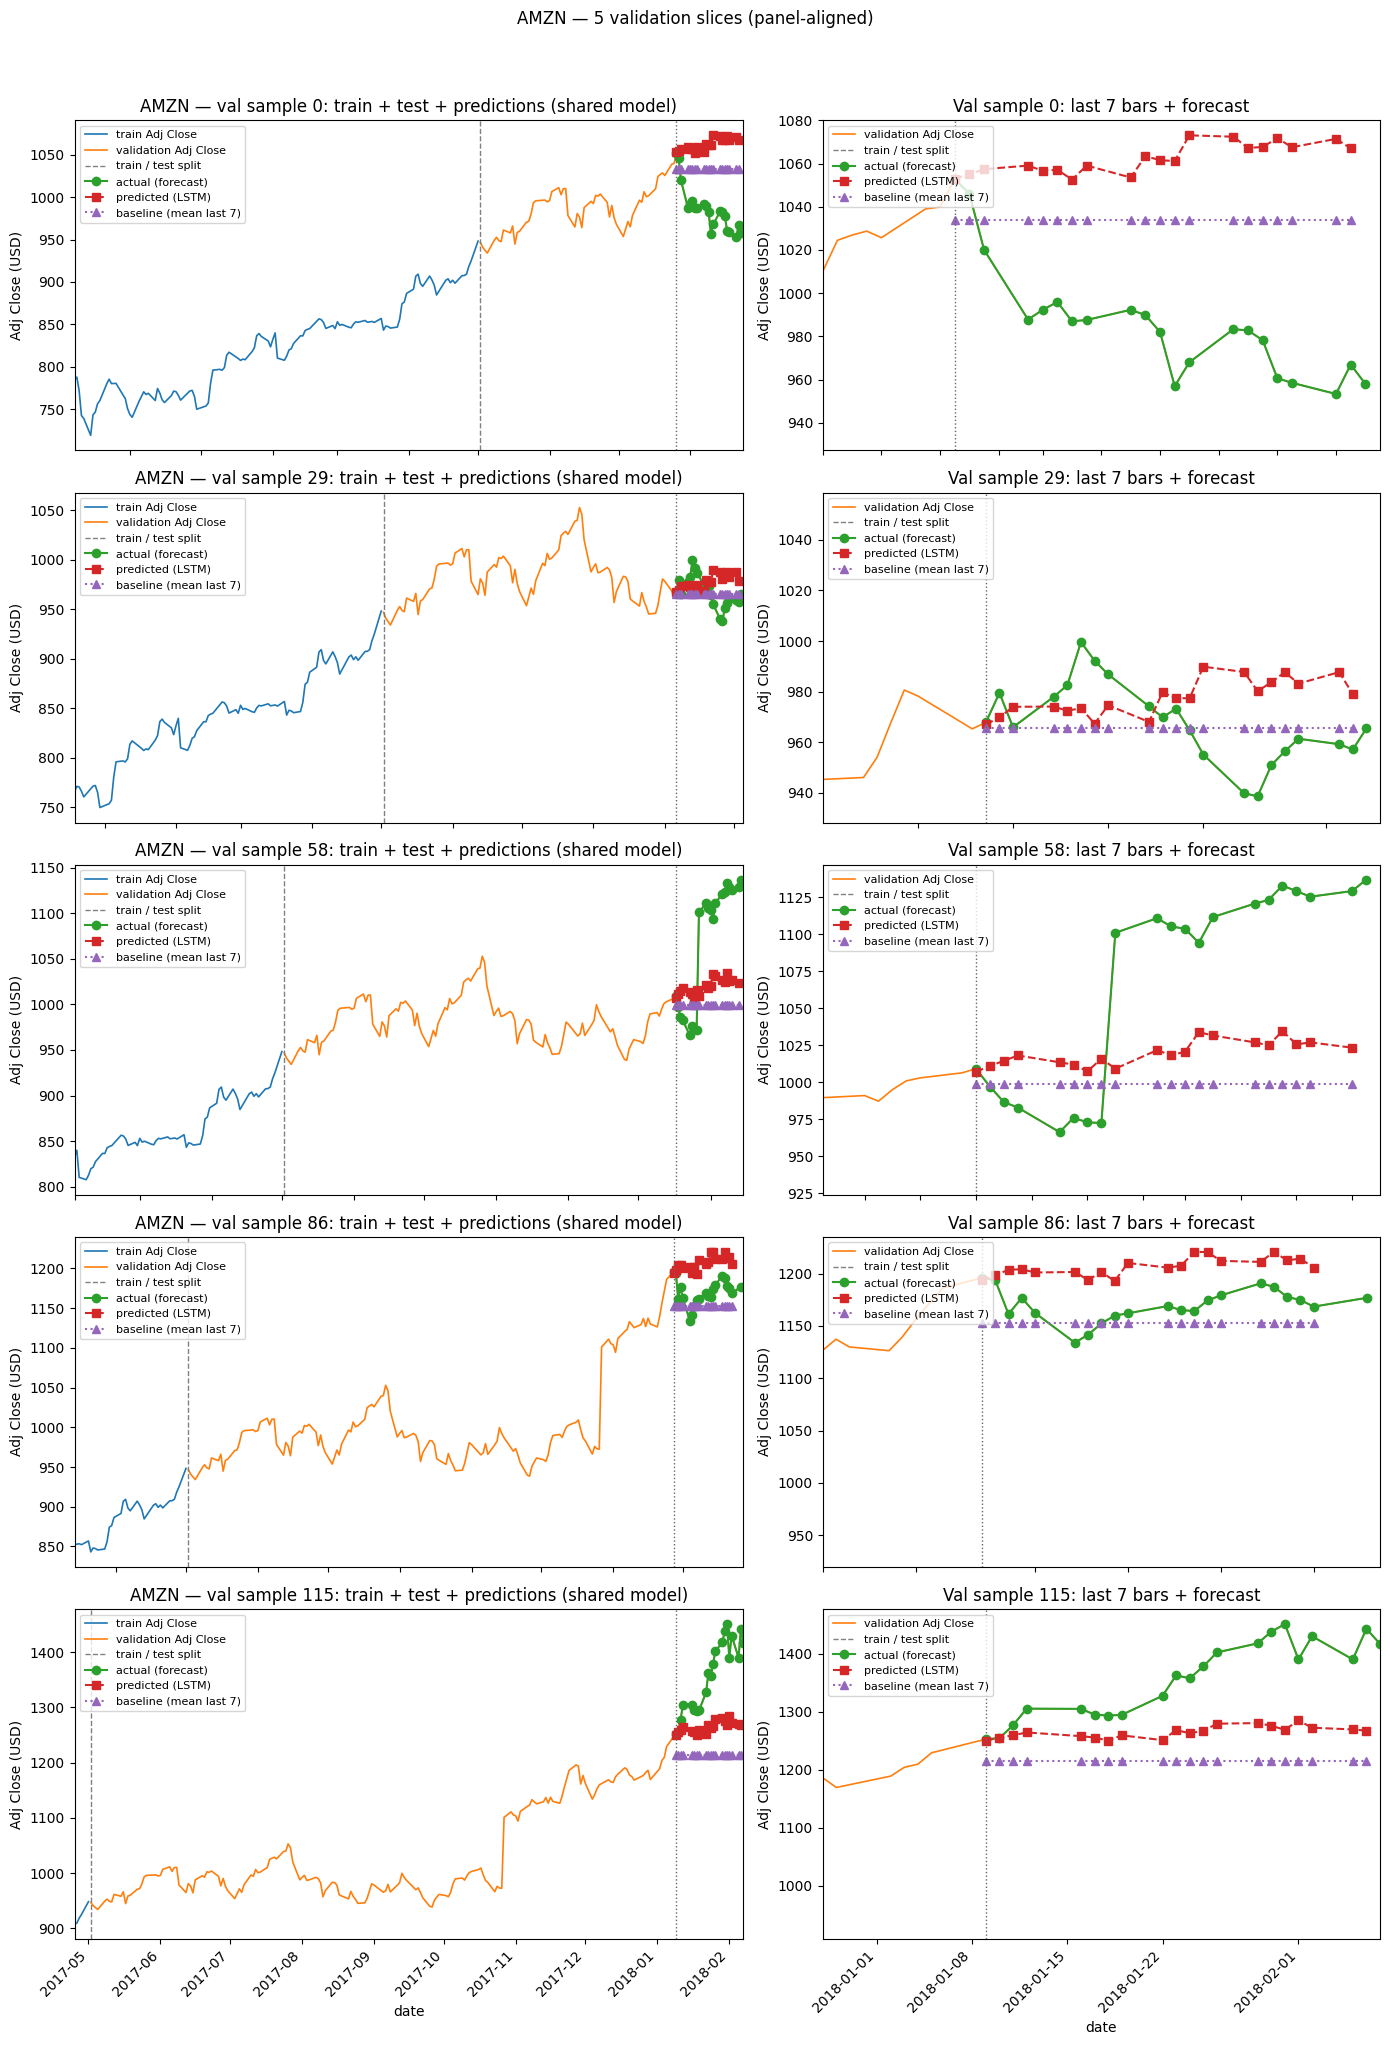

JPM Val MAE: model=2.4864 USD | rolling-7 baseline=3.1863 USD


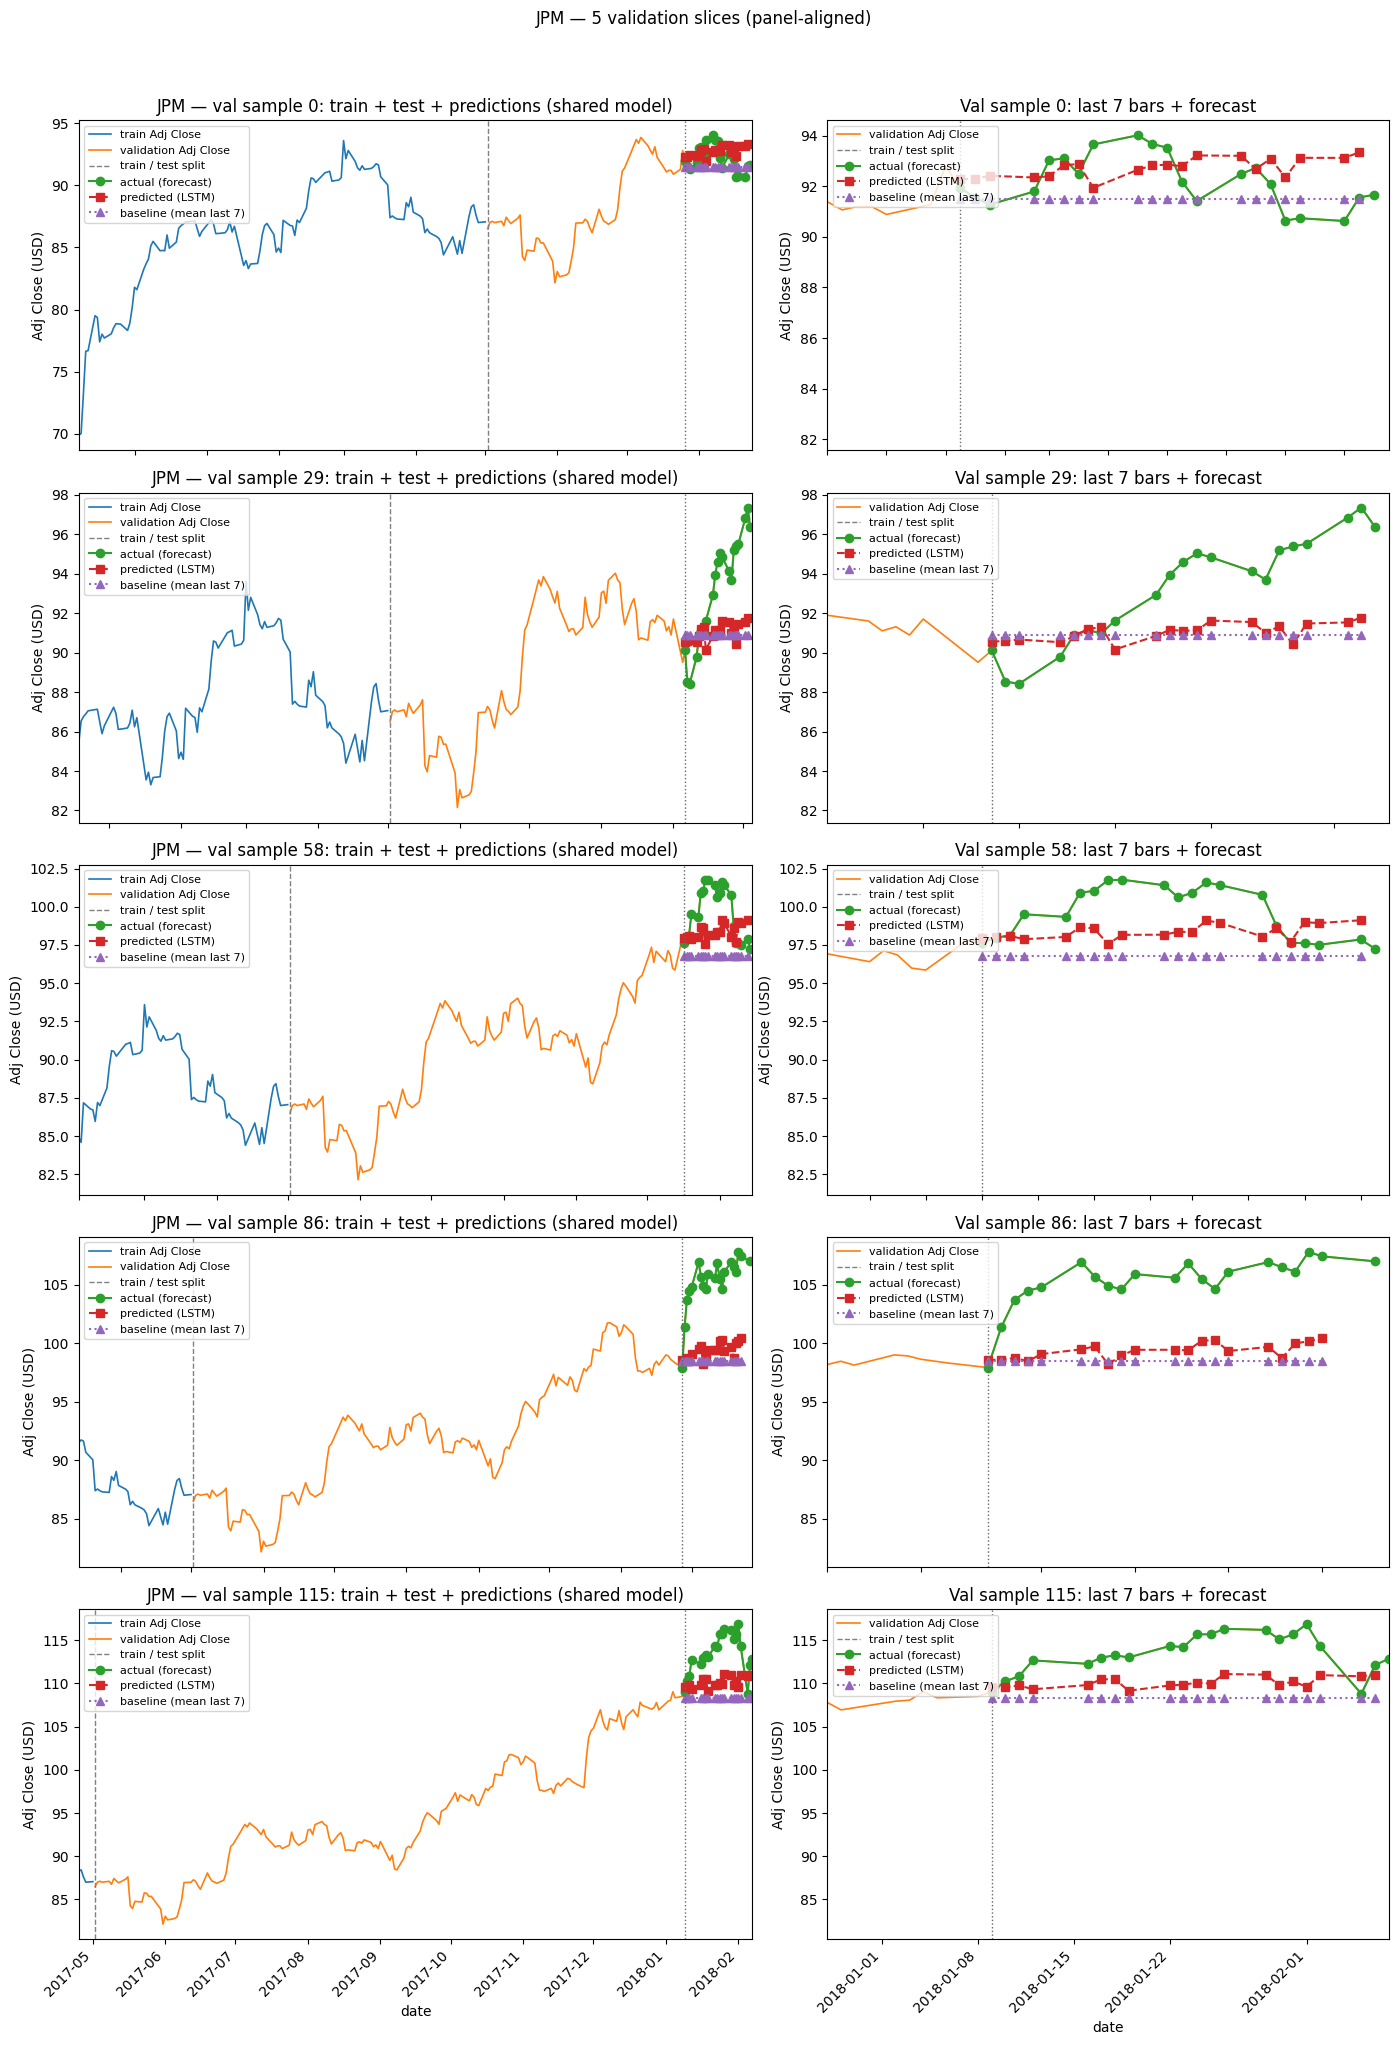

In [10]:
def adj_close_baseline_panel(panel: pd.DataFrame, split: int, idx: int, ticker: str) -> np.ndarray:
    """Rolling mean of panel prices for one ticker at forecast origin."""
    i = split + idx
    end_lookback = i + LOOKBACK - 1
    lo = max(0, end_lookback - BASELINE_WINDOW + 1)
    b = float(panel[ticker].iloc[lo : end_lookback + 1].mean())
    return np.full(HORIZON, b, dtype=np.float64)


n_bars = len(panel_prices)
split = int(n_bars * TRAIN_FRAC)
mean = scaler["mean"]
std = scaler["std"]

pred_pack = model.predict(x_val, verbose=0)
pred_val = pred_pack["adj_close_path"]

for ti, ticker in enumerate(TICKERS):
    anchor_all = x_val[:, -1, ti][:, np.newaxis]
    pred_norm_lvl = pred_val[:, ti, :] + anchor_all
    true_norm_lvl = y_val["adj_close_path"][:, ti, :] + anchor_all
    pred_c_all = pred_norm_lvl * std[ti] + mean[ti]
    true_c_all = true_norm_lvl * std[ti] + mean[ti]
    base_all = np.stack(
        [adj_close_baseline_panel(panel_prices, split, j, ticker) for j in range(len(x_val))]
    )
    mae_model = float(np.mean(np.abs(pred_c_all - true_c_all)))
    mae_base = float(np.mean(np.abs(base_all - true_c_all)))
    print(
        f"{ticker} Val MAE: model={mae_model:.4f} USD | "
        f"rolling-{BASELINE_WINDOW} baseline={mae_base:.4f} USD"
    )

    n_val = len(x_val)
    if n_val == 0:
        continue
    _k_plot = min(N_PLOT_SLICES, n_val)
    plot_indices = sorted(
        {int(round(p)) for p in np.linspace(0, n_val - 1, _k_plot)}
    )
    n_plot_rows = len(plot_indices)

    N_CONTEXT_BARS = BASELINE_WINDOW
    fig, axes = plt.subplots(
        n_plot_rows,
        2,
        figsize=(14, 4 * n_plot_rows),
        gridspec_kw={"width_ratios": [1.2, 1]},
        sharex=False,
        sharey=False,
    )
    price = panel_prices[ticker]
    dates = panel_dates

    for row, idx in enumerate(plot_indices):
        if n_plot_rows == 1:
            ax_main, ax_ctx = axes[0], axes[1]
        else:
            ax_main, ax_ctx = axes[row, 0], axes[row, 1]
        i = split + idx

        anc = x_val[idx, -1, ti]
        pred_c = (pred_val[idx, ti, :] + anc) * std[ti] + mean[ti]
        true_c = (y_val["adj_close_path"][idx, ti, :] + anc) * std[ti] + mean[ti]
        baseline_c = adj_close_baseline_panel(panel_prices, split, idx, ticker)

        x0_line = i + LOOKBACK - 1
        lo = max(0, i - 2 * LOOKBACK)
        hi = min(n_bars, x0_line + HORIZON + 1)
        if lo < split:
            t_train = dates.iloc[lo:split]
            price_train = price.iloc[lo:split]
            ax_main.plot(t_train, price_train, color="C0", linewidth=1.2, label="train Adj Close")
        t_val = dates.iloc[split:hi]
        price_val = price.iloc[split:hi]
        ax_main.plot(t_val, price_val, color="C1", linewidth=1.2, label="validation Adj Close")
        ax_main.axvline(
            dates.iloc[split], color="0.5", linestyle="--", linewidth=1, label="train / test split"
        )
        t_fut = dates.iloc[x0_line : x0_line + HORIZON]
        xf = dates.iloc[x0_line : x0_line + HORIZON + 1]
        y_bridge = np.concatenate([[price.iloc[x0_line]], true_c])
        ax_main.plot(xf, y_bridge, "o-", color="C2", label="actual (forecast)", markersize=6)
        ax_main.plot(t_fut, pred_c, "s--", color="C3", label="predicted (LSTM)")
        ax_main.plot(t_fut, baseline_c, "^:", color="C4", label=f"baseline (mean last {BASELINE_WINDOW})")
        ax_main.axvline(dates.iloc[x0_line], color="0.4", linestyle=":", linewidth=1)
        ax_main.set_ylabel("Adj Close (USD)")
        ax_main.set_xlabel("date")
        ax_main.set_title(f"{ticker} — val sample {idx}: train + test + predictions (shared model)")
        ax_main.legend(loc="upper left", fontsize=8)
        ax_main.set_xlim(dates.iloc[lo], dates.iloc[min(n_bars - 1, x0_line + HORIZON + 1)])

        lo_ctx = max(0, x0_line - N_CONTEXT_BARS)
        hi_ctx = min(n_bars, x0_line + HORIZON + 1)
        if lo_ctx < split:
            t_train_ctx = dates.iloc[lo_ctx:split]
            price_train_ctx = price.iloc[lo_ctx:split]
            ax_ctx.plot(t_train_ctx, price_train_ctx, color="C0", linewidth=1.2, label="train Adj Close")
        t_val_ctx = dates.iloc[split:hi_ctx]
        price_val_ctx = price.iloc[split:hi_ctx]
        ax_ctx.plot(t_val_ctx, price_val_ctx, color="C1", linewidth=1.2, label="validation Adj Close")
        ax_ctx.axvline(
            dates.iloc[split], color="0.5", linestyle="--", linewidth=1, label="train / test split"
        )
        ax_ctx.plot(xf, y_bridge, "o-", color="C2", label="actual (forecast)", markersize=6)
        ax_ctx.plot(t_fut, pred_c, "s--", color="C3", label="predicted (LSTM)")
        ax_ctx.plot(t_fut, baseline_c, "^:", color="C4", label=f"baseline (mean last {BASELINE_WINDOW})")
        ax_ctx.axvline(dates.iloc[x0_line], color="0.4", linestyle=":", linewidth=1)
        ax_ctx.set_ylabel("Adj Close (USD)")
        ax_ctx.set_xlabel("date")
        ax_ctx.set_title(f"Val sample {idx}: last {N_CONTEXT_BARS} bars + forecast")
        ax_ctx.legend(loc="upper left", fontsize=8)
        ax_ctx.set_xlim(dates.iloc[lo_ctx], dates.iloc[min(n_bars - 1, x0_line + HORIZON + 1)])

    fig.autofmt_xdate(rotation=45)
    plt.suptitle(f"{ticker} — {n_plot_rows} validation slices (panel-aligned)", y=1.02, fontsize=12)
    plt.tight_layout()
    plt.show()
